<a href="https://colab.research.google.com/github/mauriciodev/tec_forecast/blob/main/examples/OpenSTL_GIM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OpenSTL Tutorial with Ionosphere data

In this notebook, we will provide an example on how to use OpenSTL library with Global Ionosphere Maps data.



# Setup the environment

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import sys

Cloning from GITHUB

In [ ]:
!git clone https://github.com/chengtan9907/OpenSTL

fatal: destination path 'OpenSTL' already exists and is not an empty directory.


In [ ]:
!pip install fvcore
!pip install -e OpenSTL
#!python setup.py install
sys.path.append('/content/OpenSTL')

Obtaining file:///content/OpenSTL
  Preparing metadata (setup.py) ... done
  Attempting uninstall: OpenSTL
    Found existing installation: OpenSTL 1.0.0
    Uninstalling OpenSTL-1.0.0:
      Successfully uninstalled OpenSTL-1.0.0
  Running setup.py develop for OpenSTL


# hyperparameters


In [ ]:
pre_seq_length = 36 #the number of input maps on each sample
aft_seq_length = 12 #the number of output maps on each sample
stride = 12 #number of time steps between each sample. Set to 1 if this doesn't make sense.
batch_size = 8
epochs = 2 #00

## (IMPORTANT) Define the custom configs

We first define the training configuration, which includes several important hyperparameters for training.

Next, we define the model configuration to customize a spatio-temporal predictive learning model. For MetaVP models, the key hyperparameters are: `N_S`, `N_T`, `hid_S`, `hid_T`, and `model_type`. Users have the option to either use a config file or directly set these hyperparameters.

If a config file is preferred, the user can simply include a `config_file` key with the path to the config file in the `custom_model_config` below. Otherwise, the user can directly specify these hyperparameters in the `custom_model_config`.

In [ ]:
#method = 'ConvLSTM'
method = 'SimVP'
#NOT WORKING yet #method = 'SwinLSTM'
#simvp_translator_type = 'gSTA' #This is the spatial translator block
#simvp_translator_type = 'ViT' #This is the spatial translator block
simvp_translator_type = 'Swin' #This is the spatial translator block

custom_training_config = {
    'pre_seq_length': pre_seq_length,
    'aft_seq_length': aft_seq_length,
    'total_length': pre_seq_length + aft_seq_length,
    'batch_size': batch_size,
    'val_batch_size': batch_size,
    'epoch': epochs, #100,
    'sched': 'onecycle',
    'lr': 0.001,
    'metrics': ['mae', 'mse'],
    'opt': 'adam',
    'ex_name': 'custom_exp',
    'dataname': 'custom',
    'method': method,
    #'use_gpu': False
}


if method == 'ConvLSTM': #ConvLSTM specific hyperparameters
  custom_model_config = {
    'num_hidden': '128,128,128,128',
    'filter_size': 5,
    'stride': 1,
    'patch_size': 4,
    'layer_norm': 0,
  }
elif method == 'SimVP': #SimVP specific hyperparameters
  custom_model_config = {
      # For MetaVP models, the most important hyperparameters are:
      # N_S, N_T, hid_S, hid_T, model_type
      'model_type': simvp_translator_type,
      'N_S': 4,
      'N_T': 8,
      'hid_S': 64,
      'hid_T': 256
  }
elif method == 'SwinLSTM': #SwinLSTM specific hyperparameters
  custom_model_config = {
    'method': 'SwinLSTM_B',
    # model
    'depths' : 12,
    'num_heads' : 4,
    'patch_size' : 2,
    'window_size' : 4,
    'embed_dim' : 128,
  }


# Downloading Global Ionosphere Maps (GIM) data

In [ ]:
#downloading data from tec_forecast
!gdown 1vUnBk8SIl-ieiDpKR-Mv9Vhua2566eAd

Downloading...
From: https://drive.google.com/uc?id=1vUnBk8SIl-ieiDpKR-Mv9Vhua2566eAd
To: /content/codg_14-15.h5
100% 70.6M/70.6M [00:00<00:00, 112MB/s]


In [ ]:
import h5py
import numpy as np
f = h5py.File('codg_14-15.h5', 'r')
train_npy=np.array(f['2014']) #Train/val
train_npy = np.concatenate((train_npy[:,:,:-1,:],train_npy[:,-1:,:-1,:]),axis=1)
train_npy=np.moveaxis(train_npy, [1, 2, 3], [2,3 ,1]) #T, C, H, W

test_npy=np.array(f['2015']) #Test data
test_npy = np.concatenate((test_npy[:,:,:-1,:],test_npy[:,-1:,:-1,:]),axis=1)
test_npy=np.moveaxis(test_npy, [1, 2, 3], [2,3 ,1]) #T, C, H, W

f.close()
print("Training data:", train_npy.shape)
print("Testing data:", test_npy.shape)
vmax=train_npy.max() #this is used to plot the maps


Training data: (4380, 1, 72, 72)
Testing data: (4380, 1, 72, 72)


## Data exploration

(array([8.824254e+06, 7.900799e+06, 3.129145e+06, 1.446079e+06,
        7.742670e+05, 4.324150e+05, 1.621500e+05, 3.352500e+04,
        3.125000e+03, 1.610000e+02]),
 array([  0.  ,  15.58,  31.16,  46.74,  62.32,  77.9 ,  93.48, 109.06,
        124.64, 140.22, 155.8 ]),
 <BarContainer object of 10 artists>)

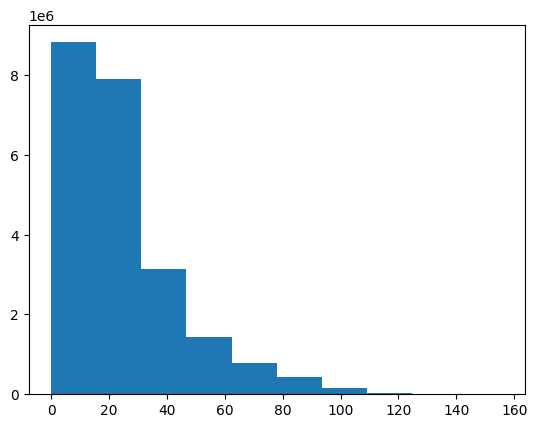

In [ ]:
plt.hist(train_npy.reshape((-1)))

## Visualize a sample

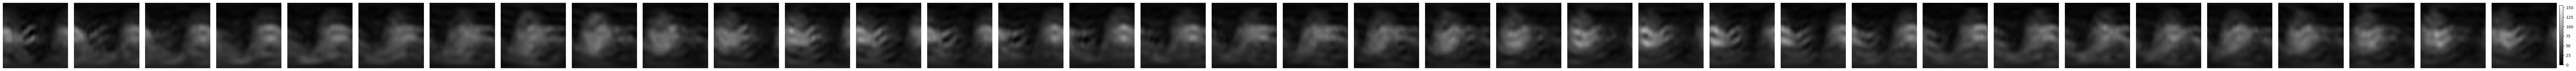

In [ ]:
from openstl.utils import show_video_line

# show the given frames from an example
example_idx = 0
show_video_line(train_npy[example_idx:example_idx+pre_seq_length], ncols=pre_seq_length, vmax=vmax, cbar=True, out_path=None, format='png', use_rgb=False)

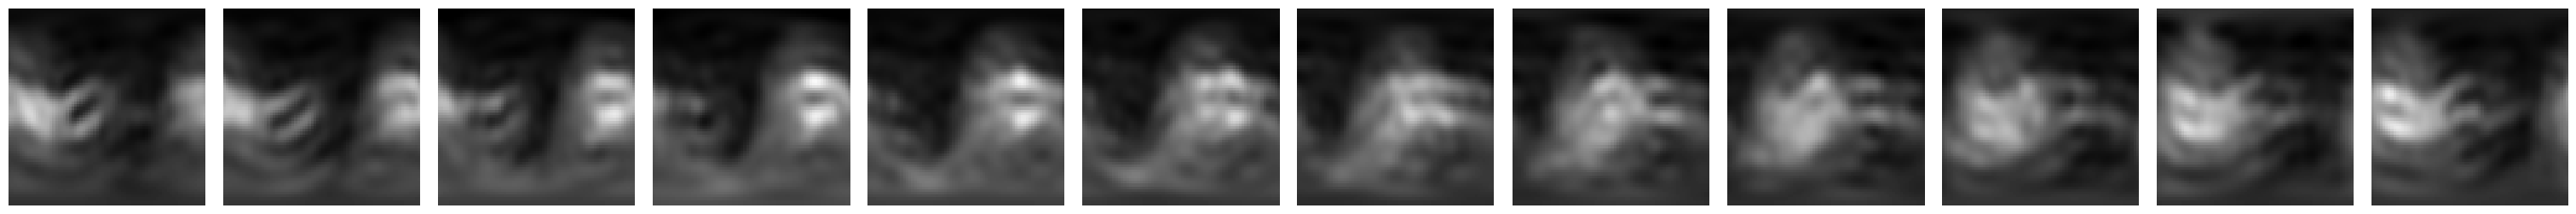

In [ ]:
# show the future frames from an example
example_idx = 0
vmax=100
show_video_line(train_npy[example_idx+pre_seq_length:example_idx+pre_seq_length+aft_seq_length], ncols=aft_seq_length, vmax=vmax, cbar=False, out_path=None, format='png', use_rgb=False)

## Torch dataset
This class is responsible for the Sliding Window time sampling and splitting the training/validation sets.

In [ ]:
import torch
from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.model_selection import train_test_split
class ionexDataset(Dataset):
    def __init__(self, npy_data, nstepsin=36, nstepsout=12, stride=12, val_split=0.2, validation_set=False, random_state=1, normalize=False, mean=0, std=0):
        self.data = npy_data.astype(np.float32)
        self.nstepsin=nstepsin
        self.nstepsout=nstepsout
        self.stride=stride
        #store the index to allow shuffling and train/val split
        self.idx=np.arange(0,len(self.data)-nstepsout-nstepsin+1,stride)

        if val_split>0:
            datasplit=train_test_split(self.idx,random_state=random_state, test_size=val_split)
            if validation_set==False: #training set
                self.idx=datasplit[0]
            else: #validation set
                self.idx=datasplit[1]

        # get the mean/std values along the channel dimension
        if mean==0 and std==0:
            mean = self.data.mean(axis=(0, 1, 2, 3)).reshape(1, -1, 1, 1)
            std = self.data.std(axis=(0, 1, 2, 3)).reshape(1, -1, 1, 1)
        if normalize:
            self.data = (self.data - mean) / std
        self.mean = mean
        self.std = std
        self.data_name = 'custom'

    def unnormalize(self):
        return (self.data * self.std + self.mean)

    def __getitem__(self, index):
        # find the end of this pattern
        i=self.idx[index]
        end_ix = i + self.nstepsin
        # check if we are beyond the sequence
        if end_ix + self.nstepsout> len(self.data):
            return None,None
        # gather input and output parts of the pattern
        seq_x, seq_y = self.data[i:end_ix], self.data[end_ix:end_ix+self.nstepsout]
        return seq_x,seq_y

    def __len__(self):
        return len(self.idx)

## Representing the numpy time sequence as samples sliced with a sliding window

In [ ]:
randomSeed = 1
train_data = ionexDataset(train_npy, nstepsin=pre_seq_length, nstepsout=aft_seq_length,
                          stride=stride, validation_set=False, val_split=0.2, random_state=randomSeed, normalize=True)
val_data = ionexDataset(train_npy, nstepsin=pre_seq_length, nstepsout=aft_seq_length,
                        stride=stride, validation_set=True, val_split=0.2, random_state=randomSeed, normalize=True)
#train_data, val_data = ionexTrainData.split_train_val(val_split=0.2)
dataloader_train = DataLoader(train_data, batch_size=batch_size, num_workers=os.cpu_count())
dataloader_val = DataLoader(val_data, batch_size=batch_size, num_workers=os.cpu_count())

#we use the mean and std scaling from the train data
ionexTestData = ionexDataset(test_npy, nstepsin=pre_seq_length, nstepsout=aft_seq_length,
                             stride=stride, normalize=True, mean=train_data.mean, std=train_data.std)
dataloader_test = DataLoader(ionexTestData, shuffle=False, batch_size=batch_size, num_workers=os.cpu_count())


for X, y in dataloader_train:
    print(f"Shape of X: {X.shape} {X.dtype} [N, C, H, W]")
    print(f"Shape of Y: {y.shape} {y.dtype}")
    break
print(f"Training samples: {len(dataloader_train.dataset)}")
print(f"Validation samples: {len(dataloader_val.dataset)}")
in_shape=X.shape[1:]
print(in_shape)

Shape of X: torch.Size([8, 36, 1, 72, 72]) torch.float32 [N, C, H, W]
Shape of Y: torch.Size([8, 12, 1, 72, 72]) torch.float32
Training samples: 289
Validation samples: 73
torch.Size([36, 1, 72, 72])


# Train and evaluate

## Setup the experiment

We retrieve the default hyperparameters by utilizing `create_parser` and update those hyperparameters that are defined in `custom_training_config` and `custom_model_config`.

By utilizing `BaseExperiment`, we ensure that everything is prepared, including dataloader setup and model initialization.

In [ ]:
from openstl.api import BaseExperiment
from openstl.utils import load_config, create_parser

#The way OpenSTL initializes hyperparameters is a bit weird
args = create_parser().parse_args([])
config = args.__dict__

#hyperparameters from the base configuration of the method
mmnist_config = f'./configs/mmnist/{method}.py'
if os.path.exists(mmnist_config):
  config.update(load_config(mmnist_config))
  #config.update(load_config(f'./configs/mmnist/{method}.py'))
#hyperparameters from training config
config.update(custom_training_config)
#hyperparameters from training config
config.update(custom_model_config)
config['in_shape']= in_shape


exp = BaseExperiment(args, dataloaders=(dataloader_train, dataloader_val, dataloader_test))
config

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


{'device': 'cuda',
 'dist': False,
 'res_dir': 'work_dirs',
 'ex_name': 'custom_exp',
 'fp16': False,
 'torchscript': False,
 'seed': 42,
 'fps': False,
 'test': False,
 'deterministic': False,
 'batch_size': 8,
 'val_batch_size': 8,
 'num_workers': 4,
 'data_root': './data',
 'dataname': 'custom',
 'pre_seq_length': 36,
 'aft_seq_length': 12,
 'total_length': 48,
 'use_augment': False,
 'use_prefetcher': False,
 'drop_last': False,
 'method': 'simvp',
 'config_file': None,
 'model_type': 'Swin',
 'drop': 0.0,
 'drop_path': 0.0,
 'overwrite': False,
 'epoch': 2,
 'log_step': 1,
 'opt': 'adam',
 'opt_eps': None,
 'opt_betas': None,
 'momentum': 0.9,
 'weight_decay': 0.0,
 'clip_grad': None,
 'clip_mode': 'norm',
 'no_display_method_info': False,
 'sched': 'onecycle',
 'lr': 0.001,
 'lr_k_decay': 1.0,
 'warmup_lr': 1e-05,
 'min_lr': 1e-06,
 'final_div_factor': 10000.0,
 'warmup_epoch': 0,
 'decay_epoch': 100,
 'decay_rate': 0.1,
 'filter_bias_and_bn': False,
 'gpus': [0],
 'metric_for_be

## Start training and evaluation

With everything in place, we are now ready to start training and evaluation.

Here we go!

In [ ]:
print('>'*35 + ' training ' + '<'*35)
exp.train()

print('>'*35 + ' testing  ' + '<'*35)
exp.test()

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> training <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type        | Params
------------------------------------------
0 | model     | SimVP_Model | 117 M 
1 | criterion | MSELoss     | 0     
------------------------------------------
117 M     Trainable params
0         Non-trainable params
117 M     Total params
468.321   Total estimated model params size (MB)


Environment info:
------------------------------------------------------------
sys.platform: linux
Python: 3.10.12 (main, Jul 29 2024, 16:56:48) [GCC 11.4.0]
CUDA available: True
CUDA_HOME: /usr/local/cuda
NVCC: Build cuda_12.2.r12.2/compiler.33191640_0
GPU 0: Tesla T4
GCC: gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
PyTorch: 2.3.1+cu121
PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.3.6 (Git Hash 86e6af5974177e513fd3fee58425e1063e7f1361)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX512
  - CUDA Runtime 12.1
  - NVCC architecture flags: -gencode;arch=compute_50,code=sm_50;-gencode;arch=compute_60,code=sm_60;-gencode;arch=compute_70,code=sm_70;-gencode;arch=compute_75,code=sm_75;-gencode;arch=compute_80,code=sm_80;-gencod

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Epoch 1: Lr: 0.0000009 | Train Loss: 0.1982116 | Vali Loss: 0.0831709


INFO: Epoch 1, global step 74: 'val_loss' reached 0.08317 (best 0.08317), saving model to '/content/work_dirs/custom_exp/checkpoints/best-epoch=01-val_loss=0.083.ckpt' as top 1
INFO: `Trainer.fit` stopped: `max_epochs=2` reached.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> testing  <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<


Testing: |          | 0/? [00:00<?, ?it/s]

mse:144825.71875, mae:19228.794921875


## Visualization

By employing the `show_video_line` and `show_video_gif_multiple` functions provided by `OpenSTL`, we can visualize the input, ground truth, and predicted frames, as well as generate corresponding GIFs.

### Visualize in a line

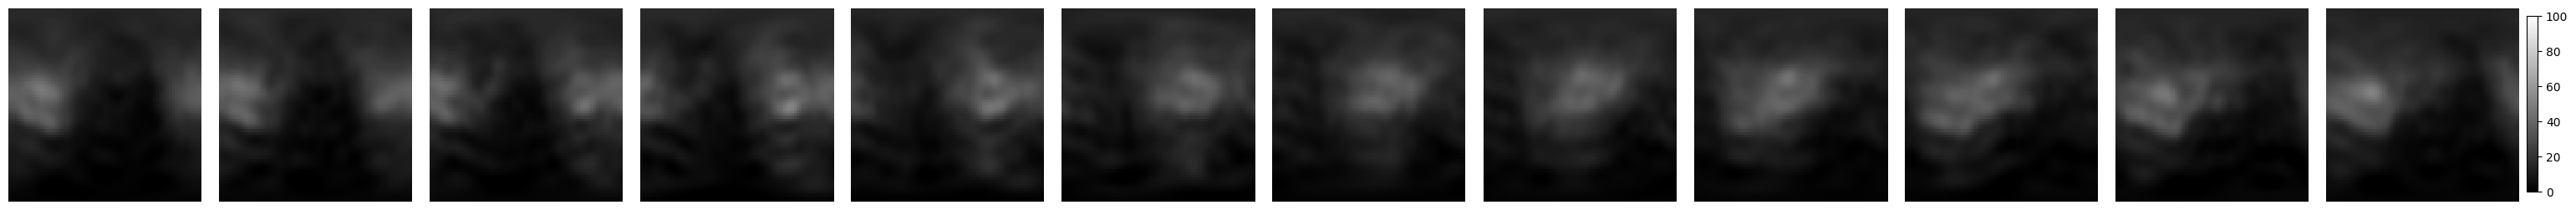

In [ ]:
from openstl.utils import show_video_line

def scale_back(m):
  return m*train_data.std+train_data.mean

# show the given frames from an example
inputs = scale_back(np.load('./work_dirs/custom_exp/saved/inputs.npy'))
preds = scale_back(np.load('./work_dirs/custom_exp/saved/preds.npy'))
trues = scale_back(np.load('./work_dirs/custom_exp/saved/trues.npy'))

example_idx = 0
show_video_line(trues[example_idx], ncols=aft_seq_length, vmax=vmax, cbar=True, out_path=None, format='png', use_rgb=False)

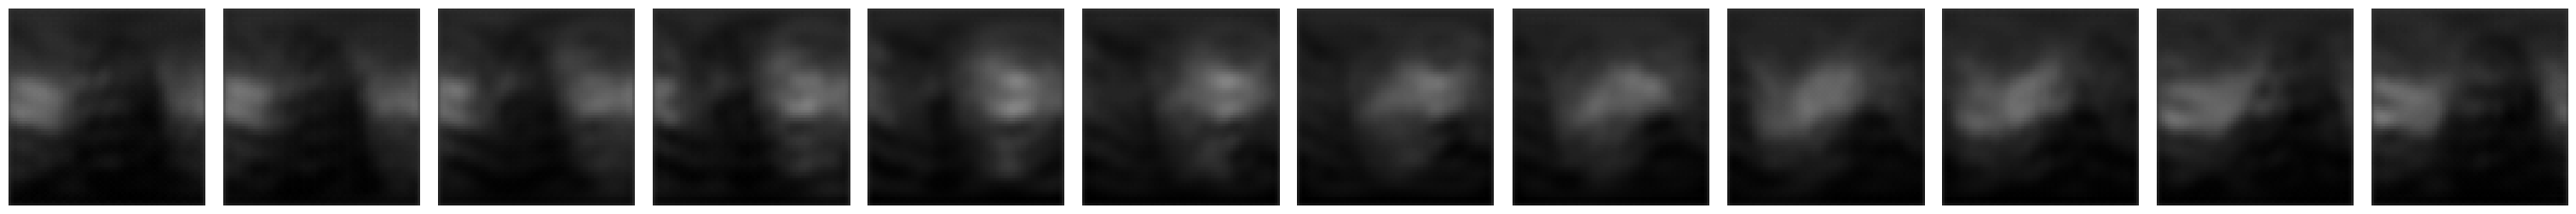

In [ ]:
example_idx = 0
show_video_line(preds[example_idx], ncols=aft_seq_length, vmax=vmax, cbar=False, out_path=None, format='png', use_rgb=False)

### Generate a GIF

In [ ]:
!pwd

/content


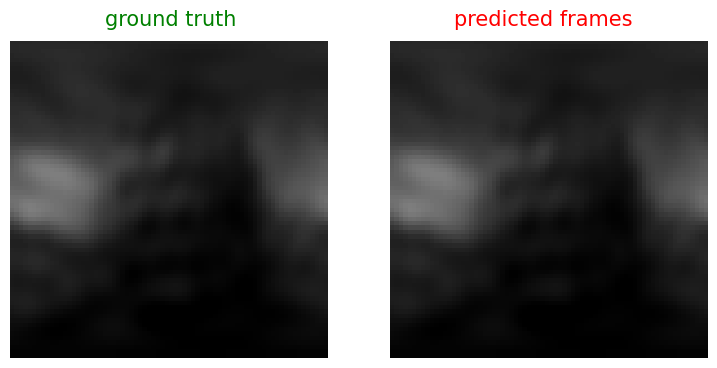

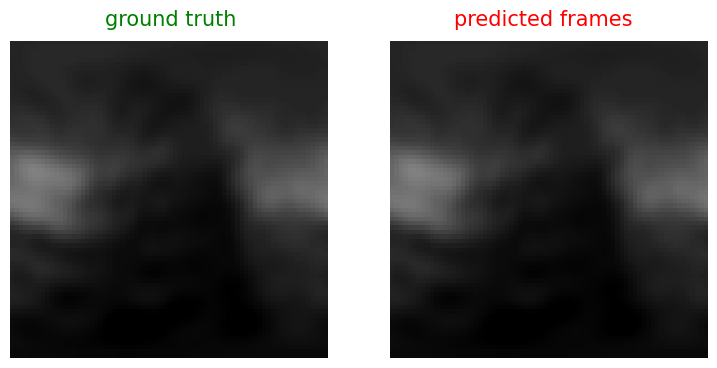

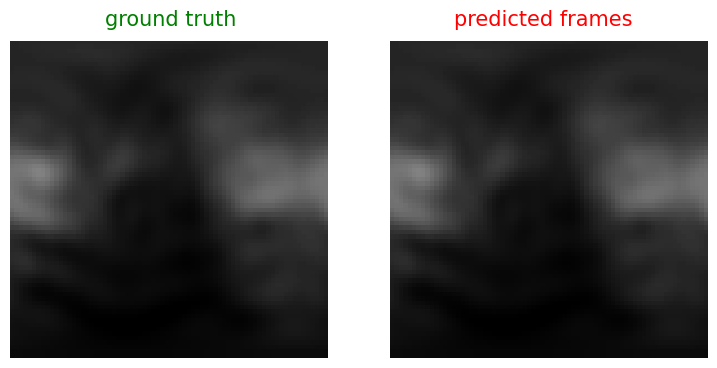

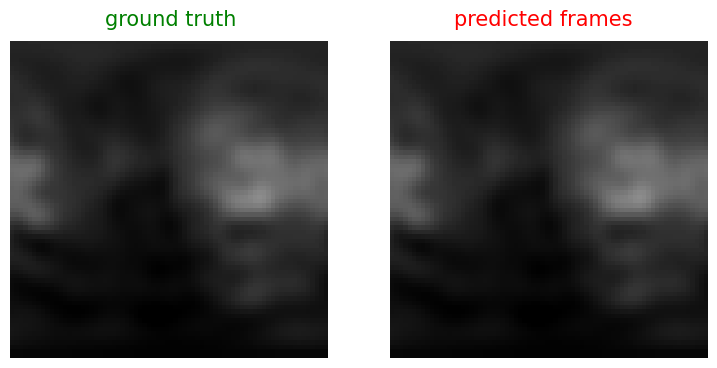

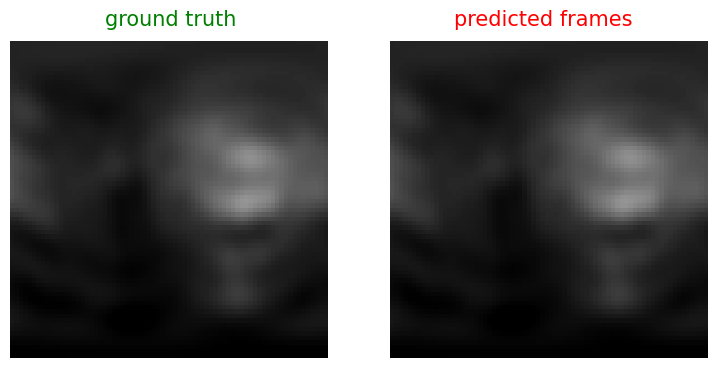

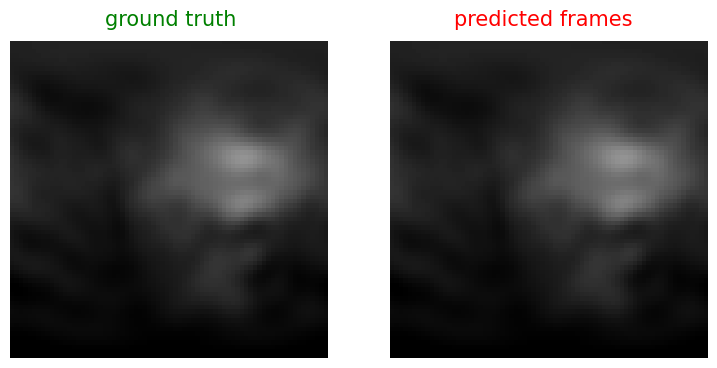

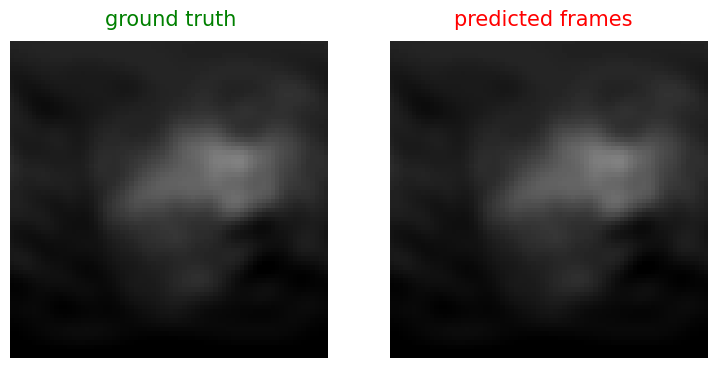

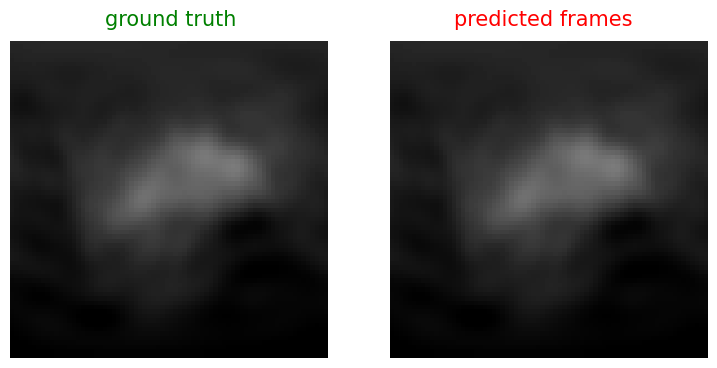

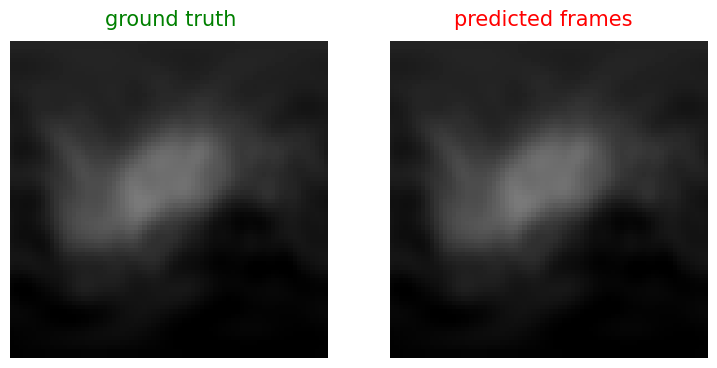

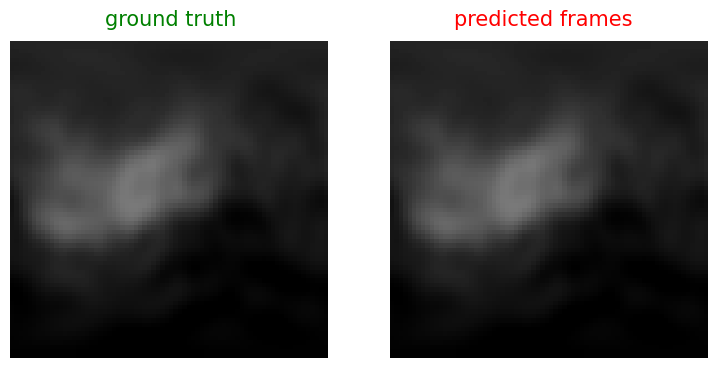

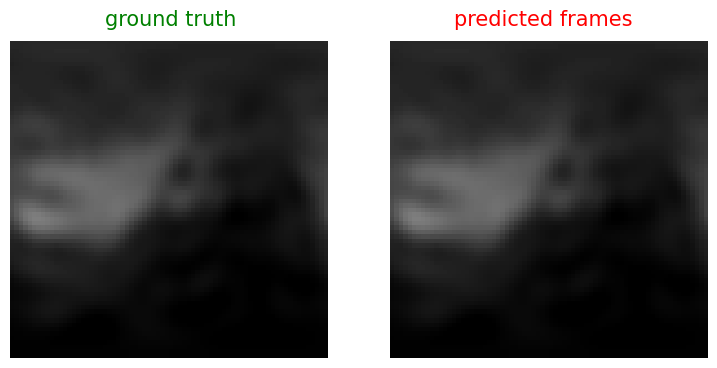

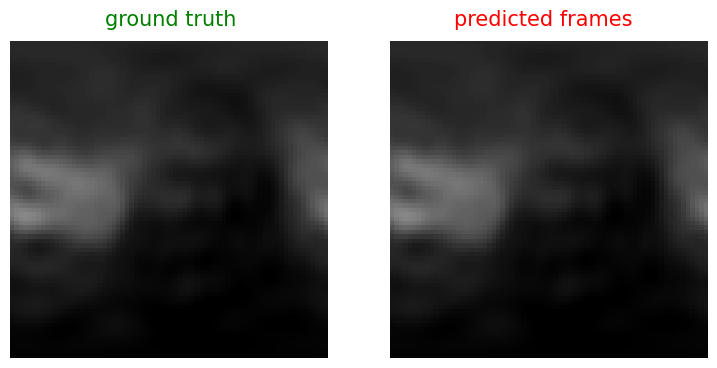

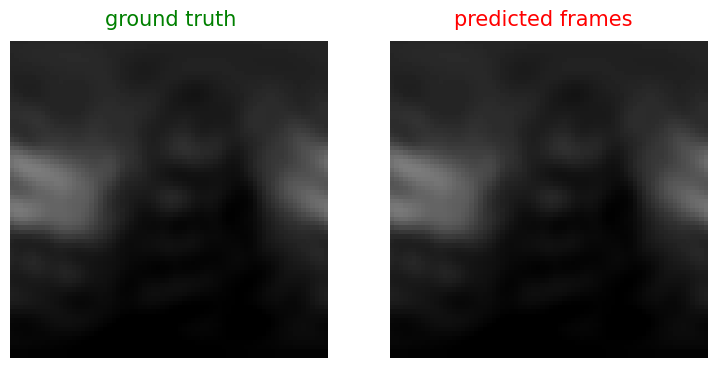

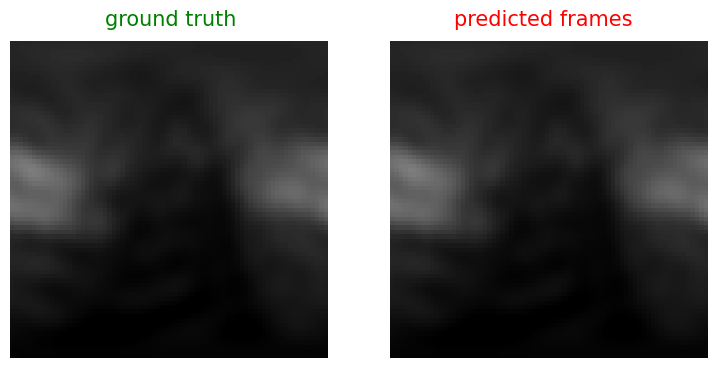

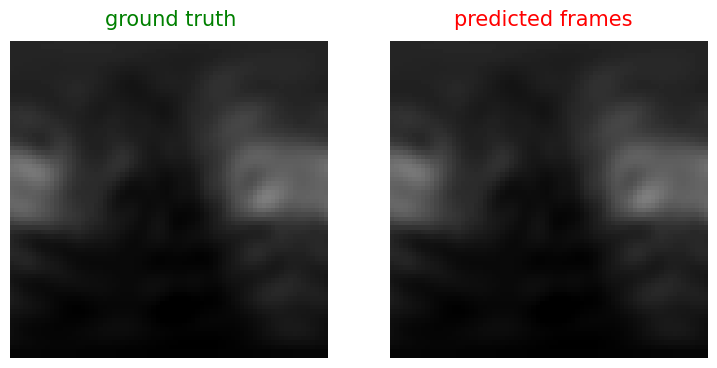

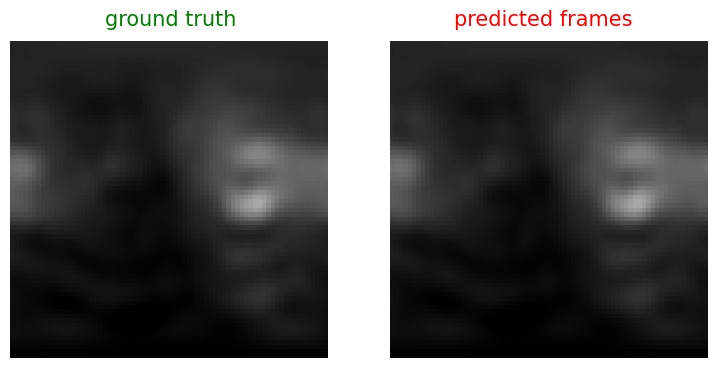

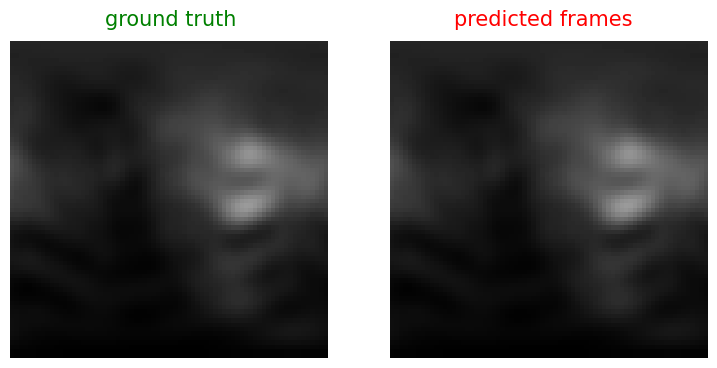

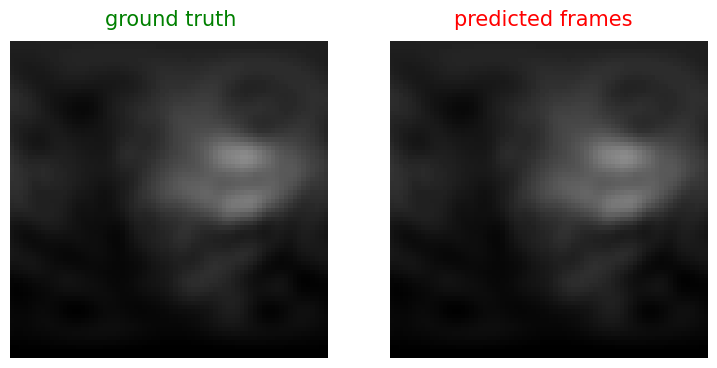

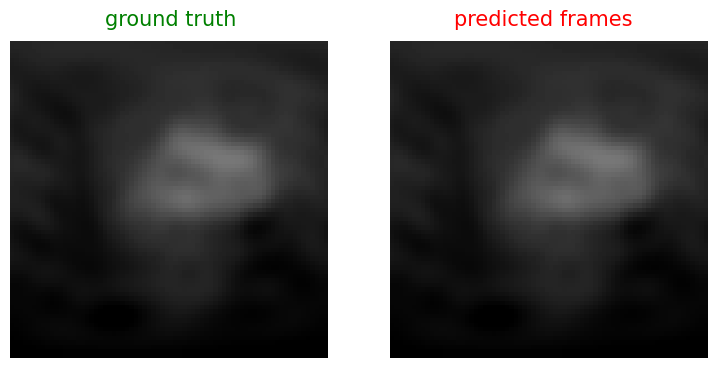

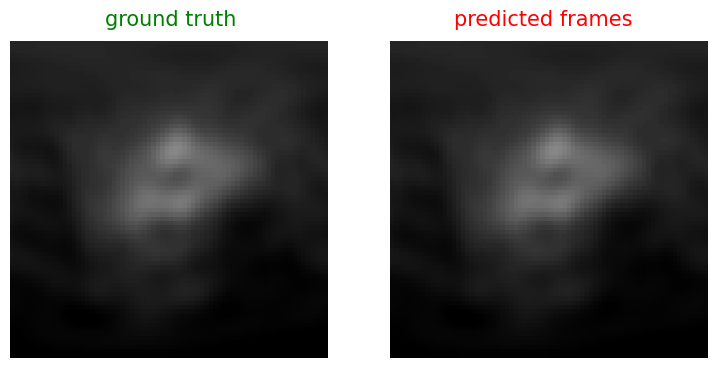

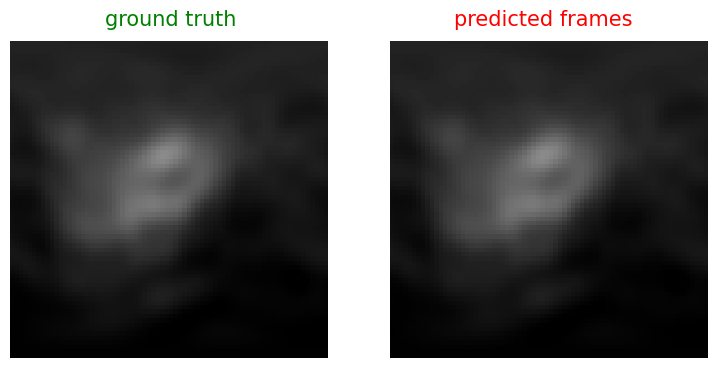

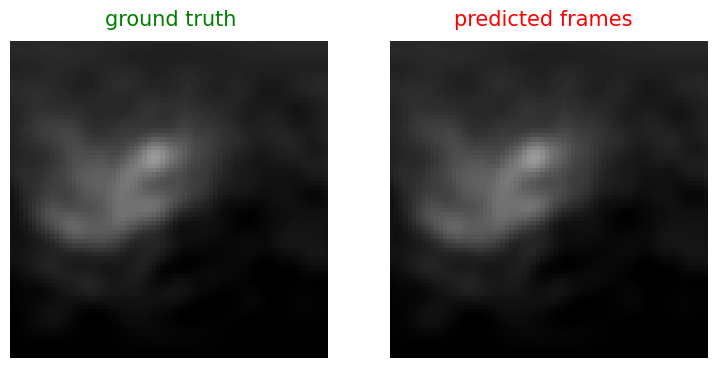

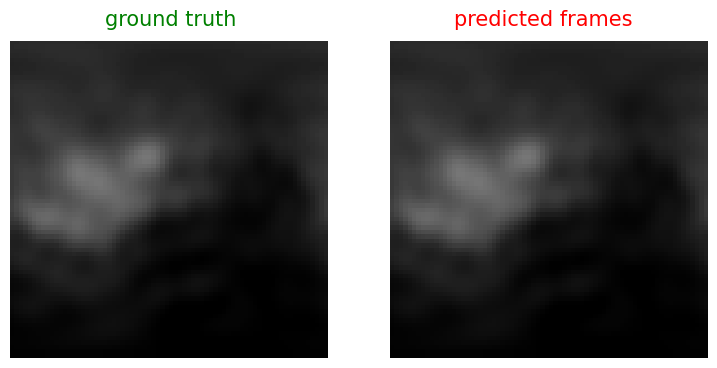

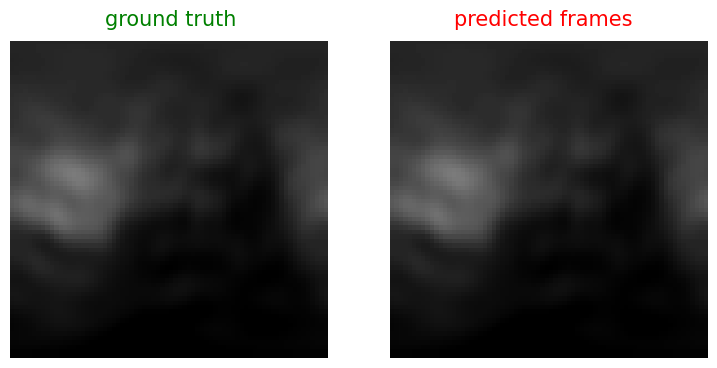

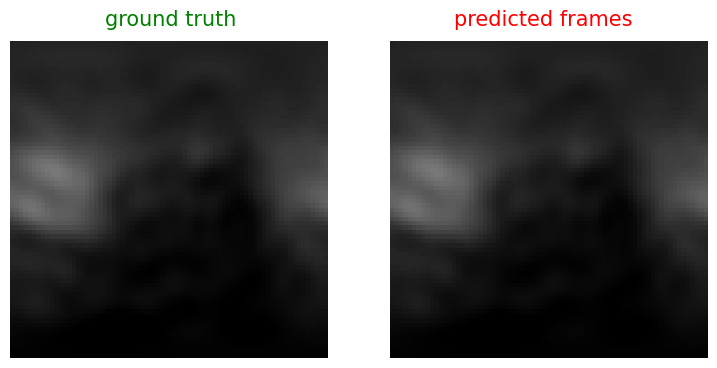

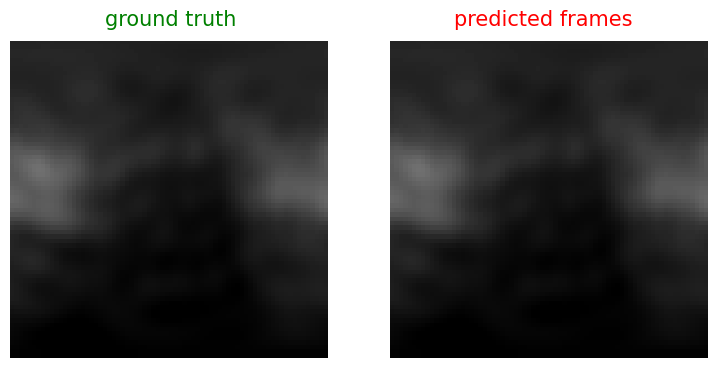

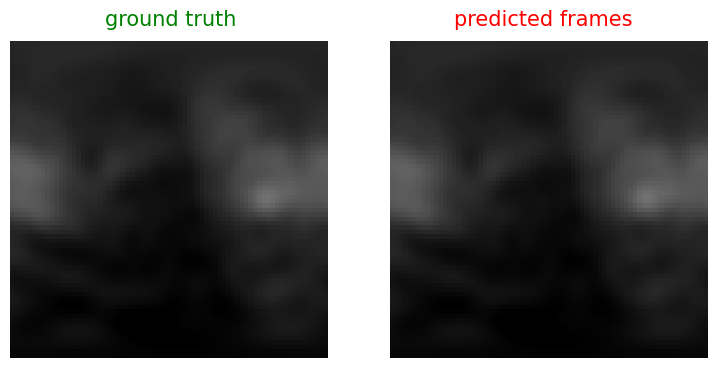

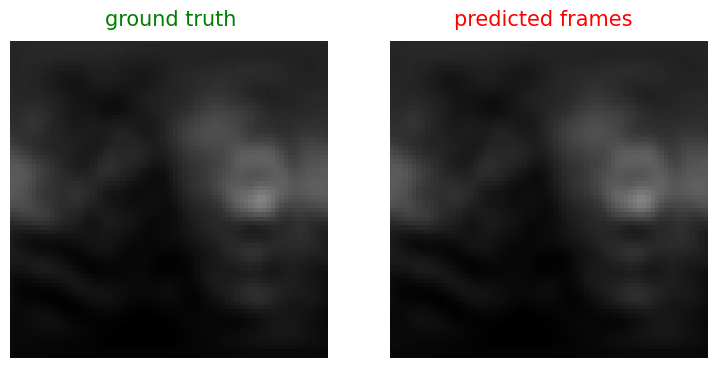

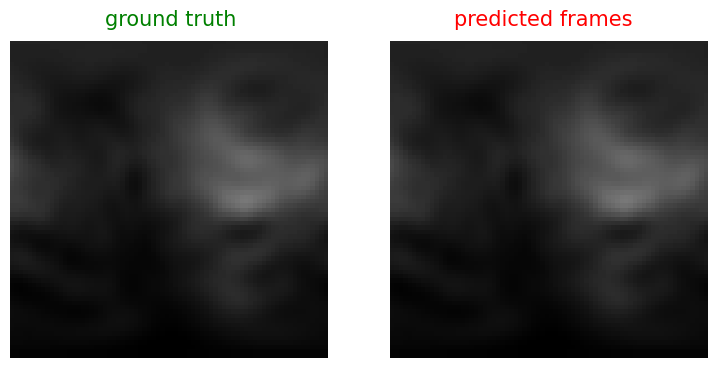

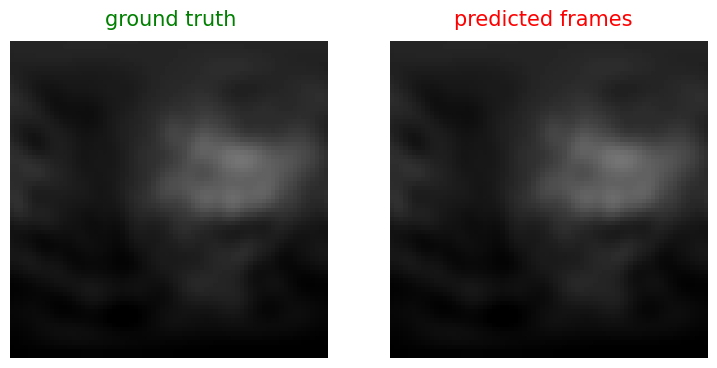

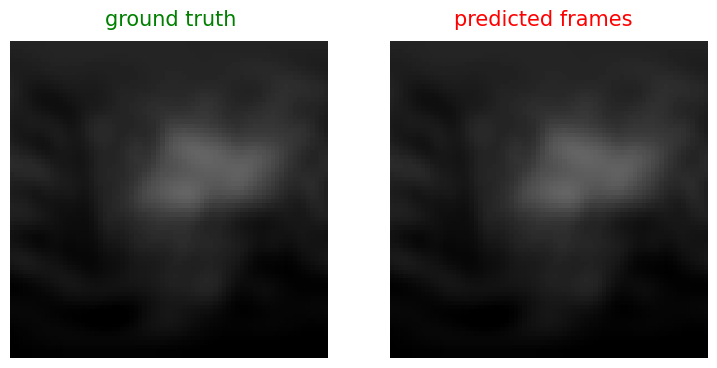

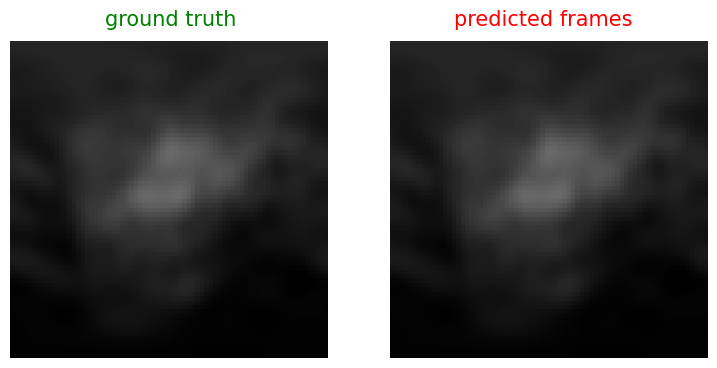

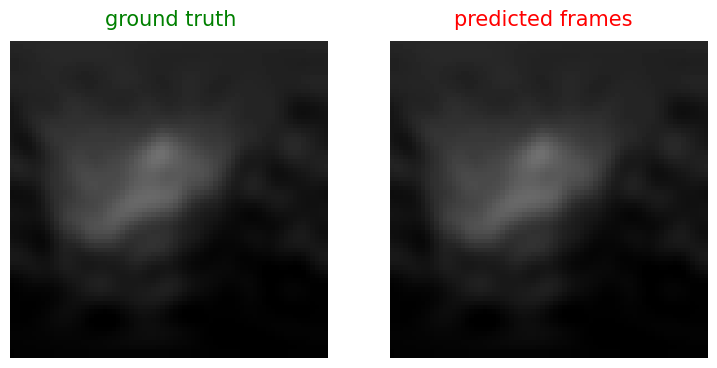

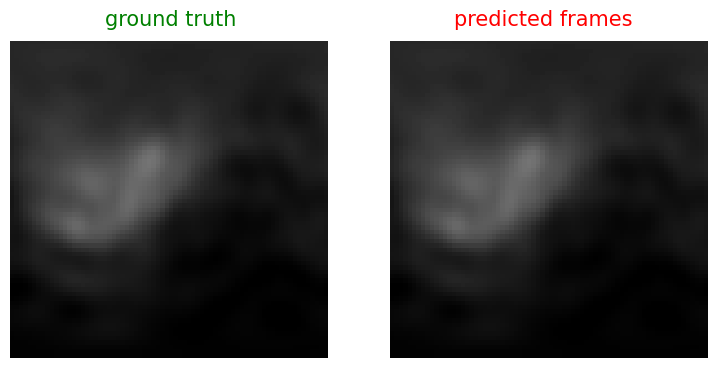

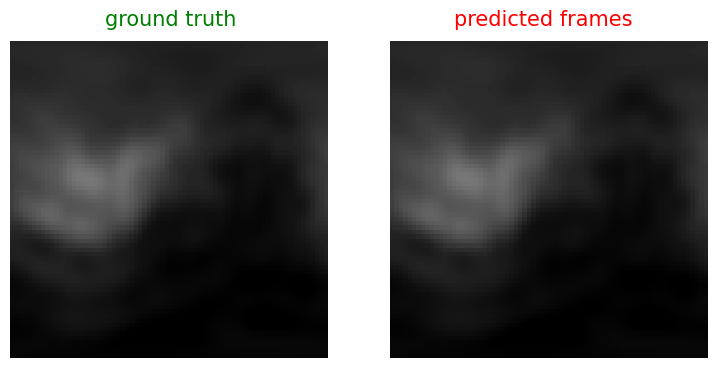

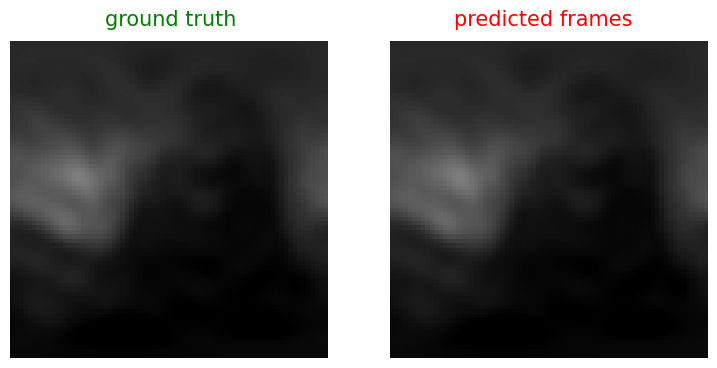

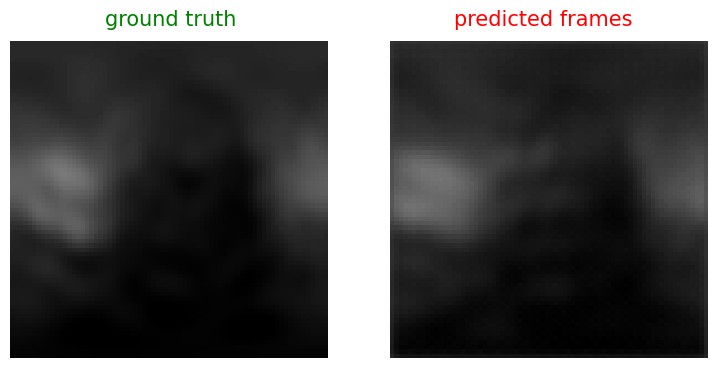

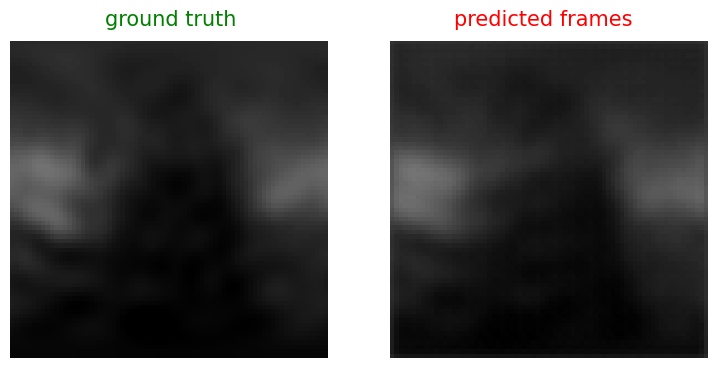

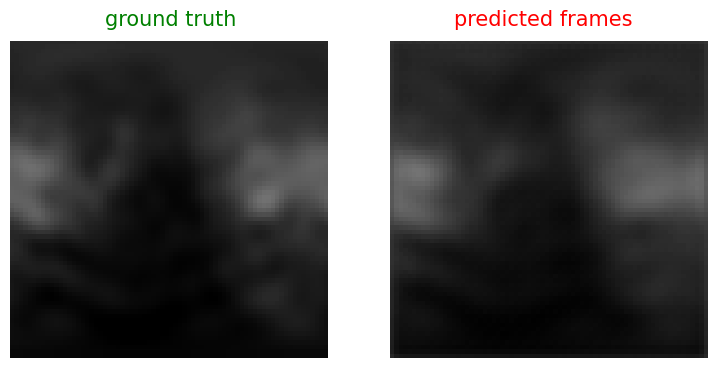

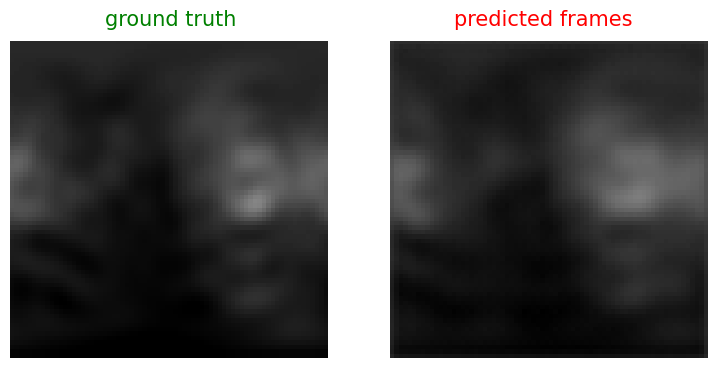

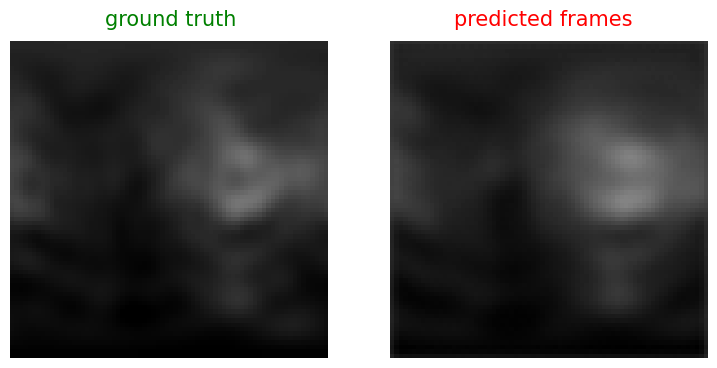

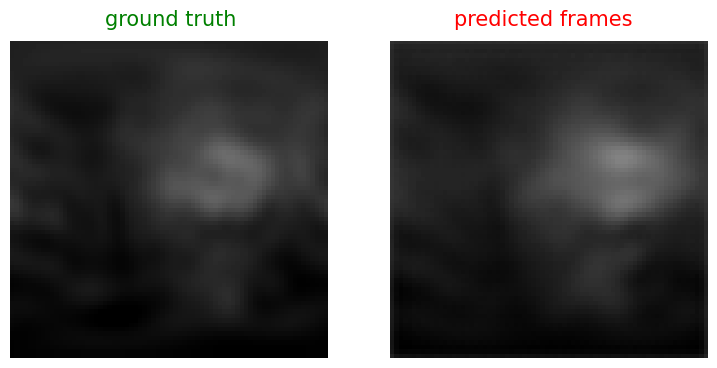

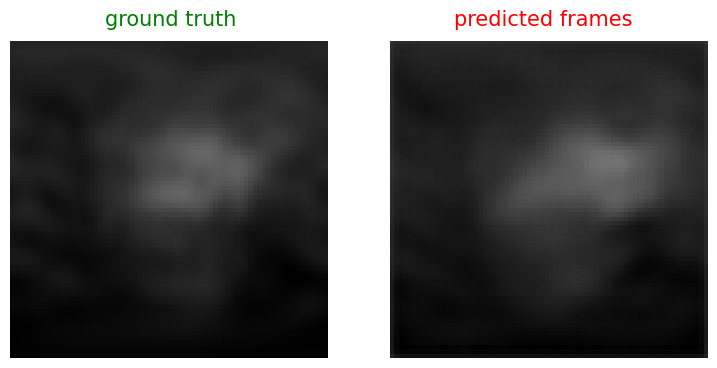

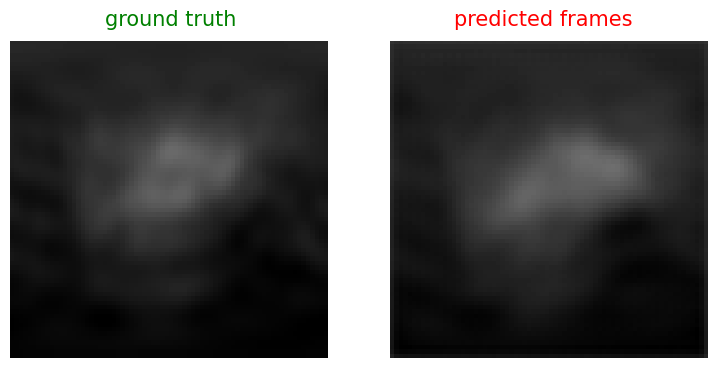

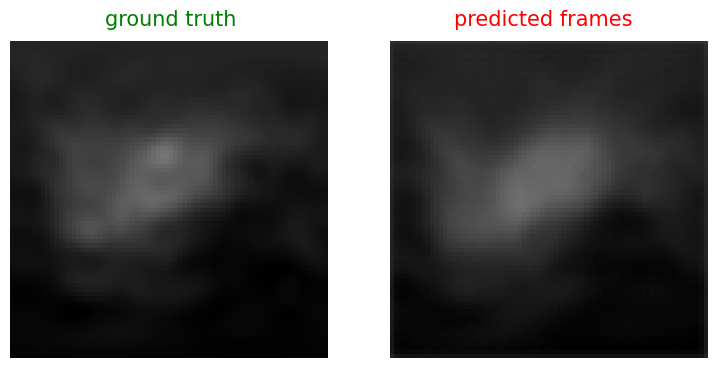

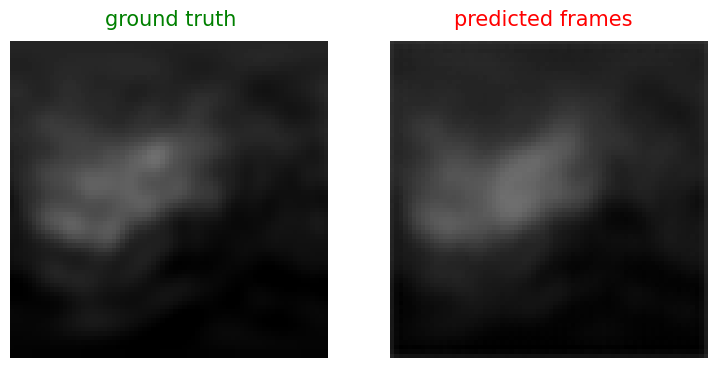

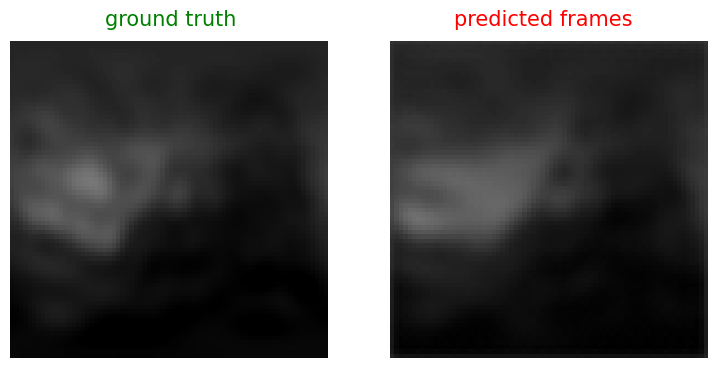

In [ ]:
from openstl.utils import show_video_gif_multiple

example_idx = 0
show_video_gif_multiple(inputs[example_idx], trues[example_idx], preds[example_idx], vmax=vmax, use_rgb=False, out_path='example.gif')

# Checking metrics without scaling

In [ ]:
import sklearn.metrics
mae = sklearn.metrics.mean_absolute_error(trues.flatten(),preds.flatten())
rmse = np.sqrt(sklearn.metrics.mean_squared_error(trues.flatten(),preds.flatten()))
r2 = sklearn.metrics.r2_score(trues.flatten(),preds.flatten())
print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2*100.:.3f}")

MAE: 3.709, RMSE: 5.286, R2: 89.460


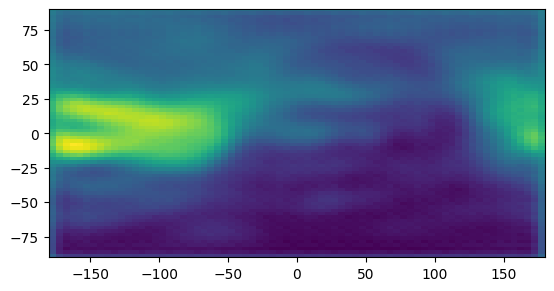

In [ ]:
sample=0
frame=11
extent = [-180,180,-90,90]
plt.imshow(np.moveaxis(preds[sample,frame], 0,2), extent=extent)

# Exporting a GIF

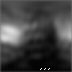

In [ ]:
import imageio
from IPython.display import Image
t=0
fname=f'pred{t}.gif'
m=preds[t]
scaled = m/(m.max()-m.min())
scaled = np.moveaxis(scaled, [1], [-1])
imageio.mimwrite(fname,(scaled*256).squeeze().astype(np.uint8), loop=0, duration = 0.3)
Image(open(fname,'rb').read())

# Saving to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
outdir = "/content/drive/MyDrive/openstl"
!echo Saving experiment to {outdir}
!mkdir -p {outdir}
!cp ./work_dirs/custom_exp/saved/ {outdir}/saved -R

MessageError: Error: credential propagation was unsuccessful